<a href="https://colab.research.google.com/github/Ethan-Z690/Dinosaur-Project-AI-Code/blob/main/Working%20copy%20of%20Ai_Dinosaur_tooth_code_6_20_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


MedNIST.tar.gz: 59.0MB [00:00, 130MB/s]                            

2026-06-19 18:22:55,259 - INFO - Downloaded: /tmp/tmpkdnoi_6a/MedNIST.tar.gz
2026-06-19 18:22:55,260 - INFO - Expected md5 is None, skip md5 check for file /tmp/tmpkdnoi_6a/MedNIST.tar.gz.
2026-06-19 18:22:55,263 - INFO - Non-empty folder exists in data/MedNIST, skipped extracting.


['HeadCT', 'BreastMRI', 'Hand', 'ChestCT', 'AbdomenCT', 'README.md', 'CXR']
Total images: 200
Epoch 1, Loss: 14.0261
Epoch 2, Loss: 10.4926
Epoch 3, Loss: 8.8603


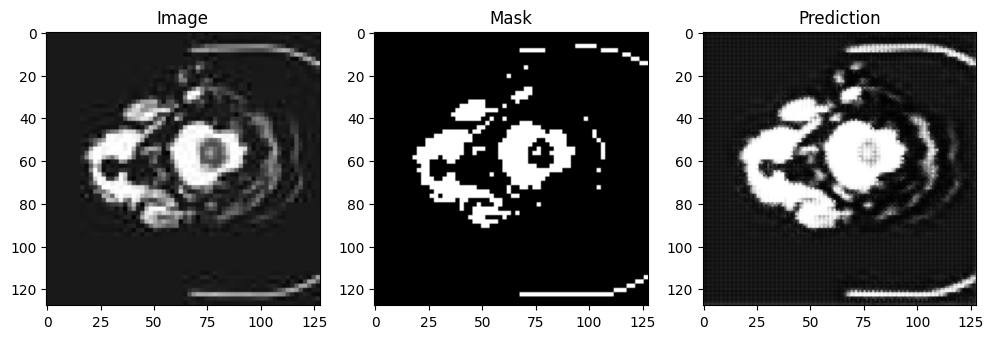

NameError: name 'uploaded' is not defined

In [9]:
!pip install -q monai nibabel matplotlib tqdm
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, ScaleIntensity,
    Resize, ToTensor
)
from monai.data import ImageDataset
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
from monai.apps import download_and_extract

url = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/MedNIST.tar.gz"
root_dir = "./data"
download_and_extract(url=url, output_dir=root_dir)

data_dir = os.path.join(root_dir, "MedNIST")
print(os.listdir(data_dir))
image_files = []
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".jpeg"):
            image_files.append(os.path.join(root, file))

image_files = image_files[:200]  # keep small for speed
print("Total images:", len(image_files))
transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
    Resize((128,128)),
    ToTensor()
])
class SimpleSegDataset(torch.utils.data.Dataset):
    def __init__(self, files, transform):
        self.files = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = self.transform(self.files[idx])

        # Fake segmentation mask (threshold)
        mask = (img > 0.5).float()

        return img, mask

dataset = SimpleSegDataset(image_files, transforms)
loader = DataLoader(dataset, batch_size=8, shuffle=True)
model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64),
    strides=(2, 2),
).to(device)

loss_fn = DiceLoss(sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 3

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")
model.eval()
imgs, masks = next(iter(loader))
imgs = imgs.to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(imgs))

# Show 1 example
i = 0
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(imgs[i][0].cpu(), cmap='gray')

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(masks[i][0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(preds[i][0].cpu(), cmap='gray')

plt.show()
from PIL import Image

fossil_images = list(uploaded.keys())

class FossilDataset(torch.utils.data.Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        img = np.array(img) / 255.0

        img = torch.tensor(img).unsqueeze(0).float()

        # Placeholder mask (replace with real labels later)
        mask = (img > 0.6).float()

        return img, mask
dataset = FossilDataset(fossil_images)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

ModuleNotFoundError: No module named 'monai'

Saving carnivore.jpg to carnivore.jpg
Samples: 1
Epoch 1, Loss: 0.6116
Epoch 2, Loss: 0.1601
Epoch 3, Loss: 0.0227
Epoch 4, Loss: 0.0024
Epoch 5, Loss: 0.0002
Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


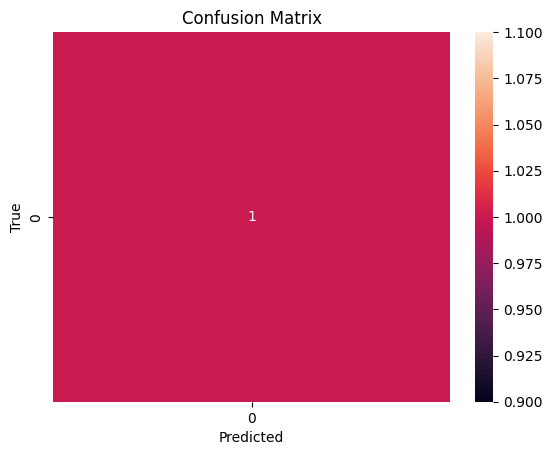

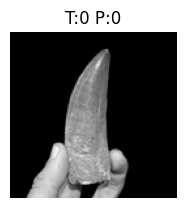

In [4]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pydicom
from google.colab import files
uploaded = files.upload()
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ToothDataset(Dataset):
    def __init__(self, file_dict):
        self.samples = []

        for fname in file_dict.keys():
            if "carnivore" in fname:
                label = 0
            elif "herbivore" in fname:
                label = 1
            else:
                continue

            self.samples.append((fname, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]

        img = Image.open(fname).convert("L").resize((128,128))
        img = np.array(img)/255.0

        img = torch.tensor(img).unsqueeze(0).float()

        return img, torch.tensor(label)

dataset = ToothDataset(uploaded)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Samples:", len(dataset))
import torch.nn as nn

class ToothCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32*32*32,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )

    def forward(self,x):
        return self.net(x)

model = ToothCNN()
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for imgs, labels in loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in loader:
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
imgs, labels = next(iter(loader))
outputs = model(imgs)
preds = torch.argmax(outputs, dim=1)

plt.figure(figsize=(10,4))

for i in range(min(6, imgs.shape[0])):
    plt.subplot(2,3,i+1)
    plt.imshow(imgs[i][0], cmap='gray')
    plt.title(f"T:{labels[i].item()} P:{preds[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()
import pydicom
from PIL import Image
import numpy as np
